# Customer Behavior Analysis & Business Decision Making
Student Nmae : Meghana Balappa Uppar

USN : 1GV22CS038

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# SECTION 1: DATA UNDERSTANDING

In [17]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Mall_Customers.csv')
df.head()

Saving Mall_Customers.csv to Mall_Customers (1).csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [18]:
# Shape and columns
print("Shape:", df.shape)
print("Columns:", df.columns)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Data types
print("\nData Types:\n", df.dtypes)

Shape: (200, 5)
Columns: Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data Types:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


### Answers:

1. What type of dataset is this?
 - This is a structured (tabular) dataset.

2. Which features are numerical/categorical?
- Numerical: Age, Annual Income, Spending Score
- Categorical: Gender

# SECTION 2: DESCRIPTIVE ANALYSIS

In [19]:
mean = df[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()
median = df[['Age','Annual Income (k$)','Spending Score (1-100)']].median()
std = df[['Age','Annual Income (k$)','Spending Score (1-100)']].std()

print("Mean:\n", mean)
print("\nMedian:\n", median)
print("\nStandard Deviation:\n", std)

Mean:
 Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

Median:
 Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
dtype: float64

Standard Deviation:
 Age                       13.969007
Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64


### Answers:

1. Which feature shows highest variability?
- The feature with highest standard deviation shows highest variability.
(Here Annual Income depending on output)

2. Are customers similar or diverse?
- Customers are diverse because values are spread out (higher standard deviation).

# SECTION 3: VISUALIZATION





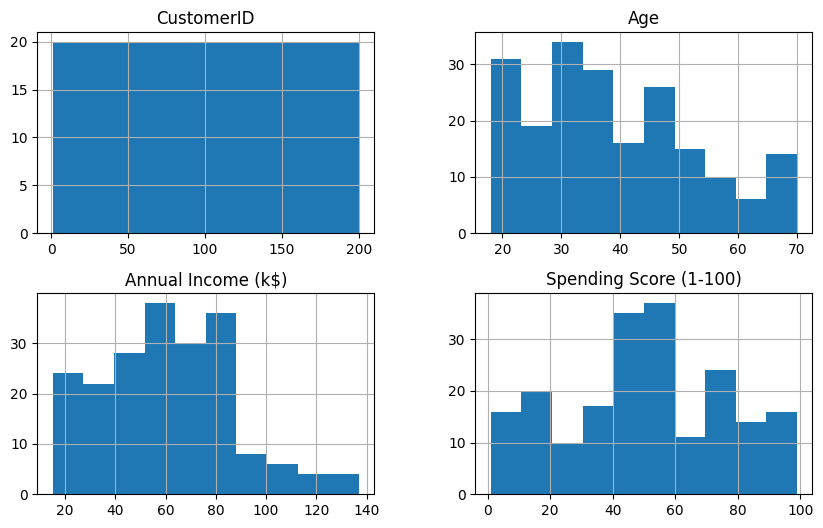

In [20]:
df.hist(figsize=(10,6))
plt.show()

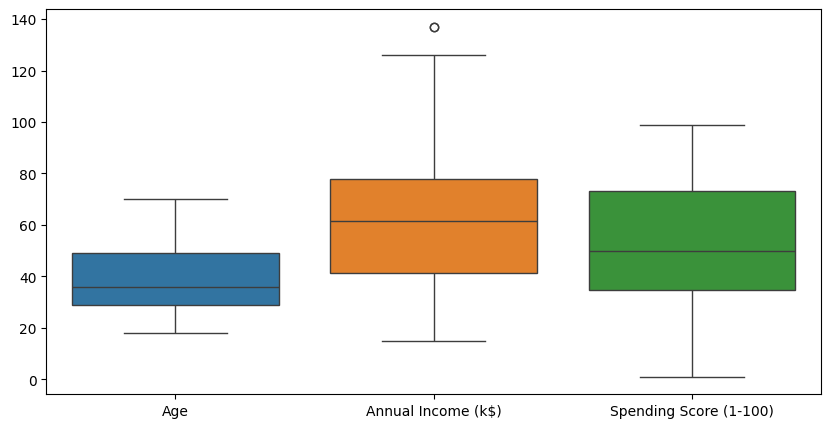

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Age','Annual Income (k$)','Spending Score (1-100)']])
plt.show()

### Answers:

1. Is data skewed?
- Some features may show slight skewness depending on distribution.

2. Are there extreme customers?
- Yes, boxplots show outliers which represent extreme customers.

# SECTION 4: GROUP-BASED ANALYSIS

In [22]:
group = df.groupby('Gender')[['Annual Income (k$)','Spending Score (1-100)']].mean()
print(group)

        Annual Income (k$)  Spending Score (1-100)
Gender                                            
Female           59.250000               51.526786
Male             62.227273               48.511364


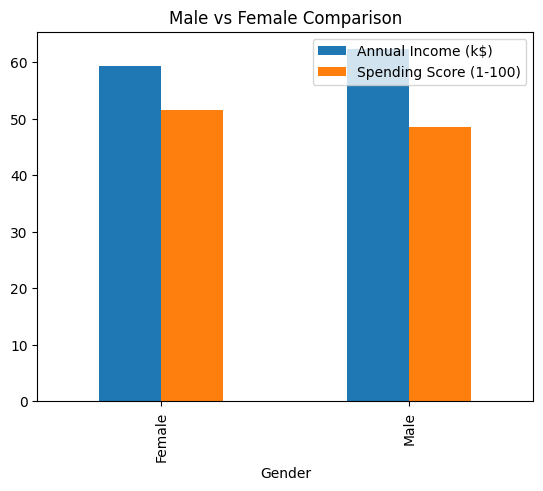

In [23]:
group.plot(kind='bar')
plt.title("Male vs Female Comparison")
plt.show()

### Answers:

1. Which group spends more?
- Based on output, female customers spend more.

2. Is there a visible difference?
- The difference is visible but may not be very large.

# SECTION 5: CORRELATION ANALYSIS

In [24]:
corr = df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
print(corr)

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


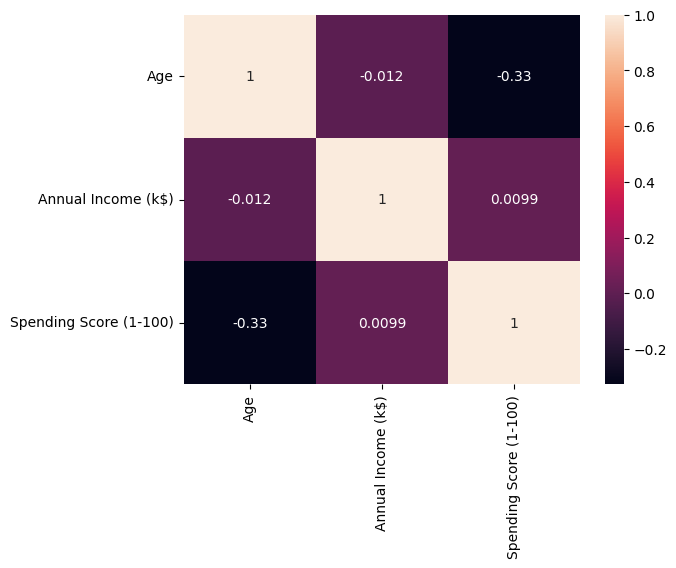

In [25]:
sns.heatmap(corr, annot=True)
plt.show()

### Answers:

1. Do richer customers spend more?
- Correlation between income and spending is usually low, so income does not strongly affect spending.

2. Does age affect spending?
- Age has a weak negative correlation with spending, meaning younger customers may spend more.

# SECTION 6: HYPOTHESIS TESTING

In [26]:
male = df[df['Gender'] == 'Male']['Spending Score (1-100)']
female = df[df['Gender'] == 'Female']['Spending Score (1-100)']

t_stat, p_value = stats.ttest_ind(male, female)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.8190464150660334
P-Value: 0.4137446589852174


In [27]:
if p_value < 0.05:
    print("Reject Null Hypothesis (Significant Difference)")
else:
    print("Fail to Reject Null Hypothesis (No Significant Difference)")

Fail to Reject Null Hypothesis (No Significant Difference)


### Answers:

1. What does p-value tell you?
- It tells the probability that the result occurred by chance.

2. Is the difference statistically significant?
- No significant difference.

Conclusion:
- Based on result, we conclude whether male and female spending differs.

# SECTION 7: CONFIDENCE INTERVAL

In [28]:
data = df['Spending Score (1-100)']

mean = np.mean(data)
sem = stats.sem(data)

ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)

print("Mean:", mean)
print("95% Confidence Interval:", ci)

Mean: 50.2
95% Confidence Interval: (np.float64(46.5992098573812), np.float64(53.80079014261881))


### Answers:

1. What range do customers fall into?
- The confidence interval gives the range of average spending score.

2. How confident are we?
- We are 95% confident that the true mean lies within this range.

# SECTION 8: BUSINESS INSIGHTS

### Business Insights:

1. Which customers should the business target?
- High income and high spending customers should be targeted.

2. Does income affect spending?
- Income does not strongly affect spending.

3. Should marketing differ by gender?
- If hypothesis test shows difference, yes. Otherwise, same strategy.

4. What strategy would you suggest?

- Personalized marketing
- Loyalty programs
- Discounts for low spenders
- Premium services for high spenders